# Avance de Proyecto
**Curso:** Ciencias de Datos

## Descripción:

En esta fase inicial, relizarás un análisis profundo sobre los factores que influyen en la supervivencia de los pasejeros durante el Hundamiento del Titanic, incluye variables demográficas y características de los pasajeros como edad, sexo, clase del boleto, tarifa pagada y puerto de embarque.

El objetivo es eexplorar cómo estes variables se realcionan con la probabilidad de superviencia, identificando patrones y tendencias que permitan entender mejor qué factores tuvieron mayor impacto en este evento histórico.

## Objetivo del Avance de Proyecto

El objetivo de este avance de proyecto es ejecutar un análisis exploratorio para adapatarnos y entender las caracteristicas fundamentales, como son las tendencias y patrones en este caso, podemos ver como esto se aplica en preguntas relacionadas con el Titanic, que estas preguntas nos ayudan para obtener datos y visualizaciones de los resultados de estas preguntas. 

 

### Parte1. CARGA DE DATOS

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    df = pd.read_csv('train.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")

# Visualización rápida de los datos
df.head()

Dataset cargado exitosamente.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Parte 2. Análisis Descriptivo

## Análisis Descrptivo

El análisis descriptivo nos permite resumir las carasterísticas de un conjunto de datos, como podemos ver en esta situación entenderemos:

**Medidas de tendencia central:** Media, mediana y moda de variables como la edad de los pasajeros, la tarifa pagada y otras variables numéricas relevantes.

**Medidas de dispersión:** Desviación estándar y rangos para analizar la variabilidad en variables como la edad, costo del boleto y otras características.

**Identificacion de variables clave:** Determinar qué factores ( como el genero, la clase del pasajero, la edad, el puerto de embarque y la tarifa) posrían tener mayor relación con la supervivencia de los pasajeros durante el Hundimiento del Titanic.

In [10]:
# ===============================
# PARTE 2: Análisis Exploratorio 
# ===============================

# 1 Información general del dataset (tipos de datos y nulos)
print("--- Información del Dataset ---")
print(df.info())

# 2 Estadísticas descriptivas de variables numéricas
print("\n--- Estadísticas Univariadas ---")
display(df.describe())

# 3 Identificación de variables categóricas clave
print("\n--- Conteo de categorías en variables clave ---")

# Sexo de los pasajeros
print("\nSexo: ")
print(df['Sex'].value_counts())

# Clase de pasajero
print("\nClase (Pclass): ")
print(df['Pclass'].value_counts)

# Puerto de embarque
print("\nPuerto de embarque (Embarked): ")
print(df['Embarked'].value_counts)

# 4 Analisis de supervivencia
print("\n--- Supervivencia ---")
print(df['Survived'].value_counts())


# 5 Relacion entre variables y supervivenica (promedios)
print("\n--- Supervivencia por sexo ---")
print(df.groupby('Sex')['Survived'].mean())

print("\n --- Supervivencia por clase ---")
print(df.groupby('Pclass')['Survived'].mean())

# 6 Creación de nueva variable: tamaño de familia
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("\nPrimeras filas con nueva variable FamilySize:")
df.head()

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

--- Estadísticas Univariadas ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Conteo de categorías en variables clave ---

Sexo: 
Sex
male      577
female    314
Name: count, dtype: int64

Clase (Pclass): 
<bound method IndexOpsMixin.value_counts of 0      3
1      1
2      3
3      1
4      3
      ..
886    2
887    1
888    3
889    1
890    3
Name: Pclass, Length: 891, dtype: int64>

Puerto de embarque (Embarked): 
<bound method IndexOpsMixin.value_counts of 0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str>

--- Supervivencia ---
Survived
0    549
1    342
Name: count, dtype: int64

--- Supervivencia por sexo ---
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

 --- Supervivencia por clase ---
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Primeras filas con nueva variable FamilySize:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


## Parte 3. Visualizacion de Datos 

Esta parte es muy importante ya que utilizaremos herramientas que nos permiten visualizar nuestros datos

1. **Histogramas:** Para observar la distribucion de variables numericas como la edad y la tarifa pagada de los pasajeros.

2. **Box Plots:** Para identificar valores atipicos y comprar variables como la tarfia o la edad entre diferentes grupos, un ejemplo seria entre clases o si no, entre hombres y mujeres.

3. **Dispercion:** Para explorar la relación entre variables numericas, se incorporará una nueva variable derivada (como el tamaño de la familia a partir de *SibSp* y *Parch*), ya que eso permite una mejor interaccion con los datos y facilita la identificacion de patrones más claros en comparación con analizar cada variable por separado.

4. **Mapa de calor:** Esto no sirve para representar visualmente la intensidad de la relacion entre variables numericas como edad, tarfia numero de familiares a bordo y supervivencial, aparte, la inclusion de variables dervidads permite ampliar el analisis de correlacion, ayudando a detectar de manera precisa que factores influyeron en la supervivencia durante el evento.

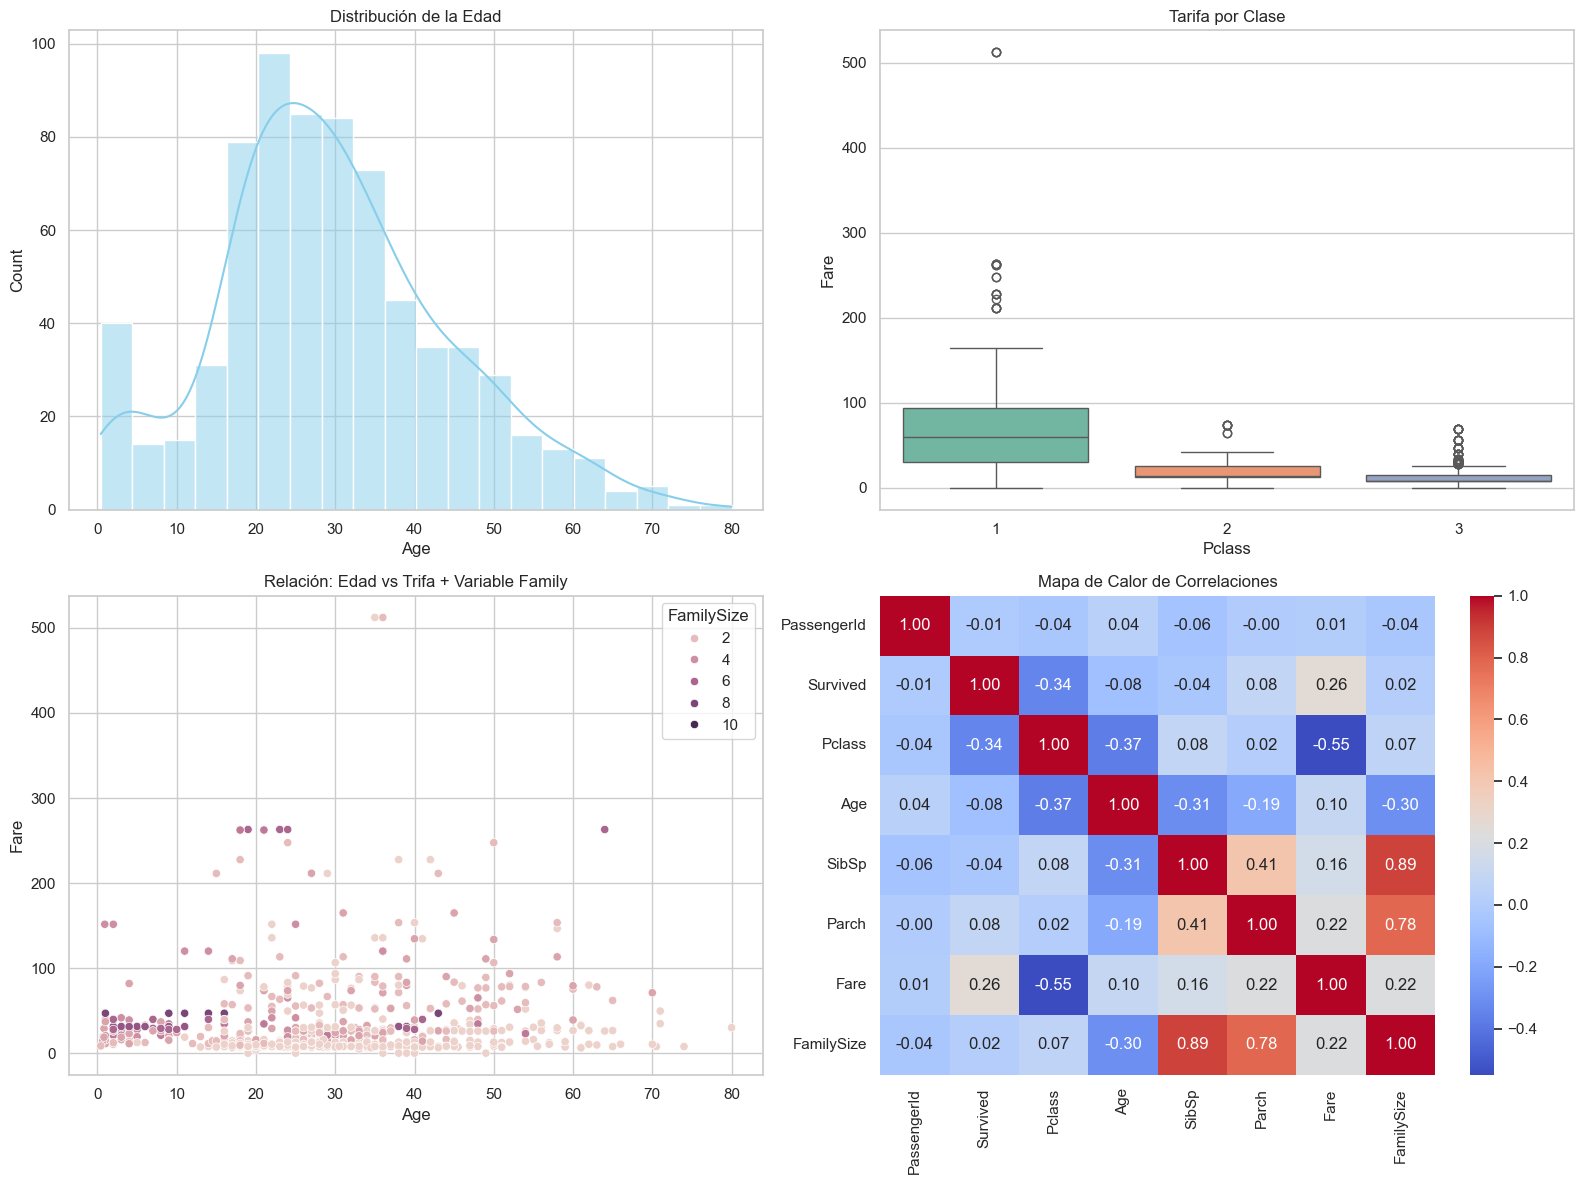

In [13]:
# =================================
# PARTE 3: Visualización de Datos
# =================================
import warnings
warnings.filterwarnings('ignore')

# Crear una figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1 Histograma: Distribución de la edad
sns.histplot(df['Age'], kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de la Edad')

# 2 Box Plot: Trifa por Clase
sns.boxplot(x='Pclass', y='Fare', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Tarifa por Clase')

# 3 Scatter Plot: Edad vs Trfia (con la nueva variable family integrada)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.scatterplot(x='Age', y='Fare', hue='FamilySize', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Relación: Edad vs Trifa + Variable Family')

# 4. Mapa de Calor: Correlaciones
# Solo tomamos columnas numéricas
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Mapa de Calor de Correlaciones')

plt.tight_layout()
plt.show()


## Parte 4. Hallagazgos e intepretacion

Tras realizar el análisis exploratorio, se puede documentar las siguientes observaciones iniciales:

1. **Relación con la Supervivencia:** Se observa que variables como el sexo y la clase de pasajero osea *Pclass* tienen un relación importante con la supervivencia. Por ejemplo, las mujerres y los pasajeros de clases más altas presentan mayores probabiidades de sobrevivir.

2. **Influencia de la Tarifa:** A partir del análisis de dispersion, se identifica que los pasajeros que pagaron tarifas más altas tienden a concentrarse en zonas con amyor probabilidad de supervivencia, lo que esto indica una relación entre el nivel economico y las porbabilidades de sobrevivir.

3. **Distribucion de Variables:** La mayoria de los pasajeros se concetra en ciertos rangos de edad y trafia, aunque existen valores atipicos, especialmente en la variable *Fare*, donde algunos pasajeros pagaron cantidades consideradamente más altas que el promedio.

4. **Variables Críticas:** Factores como el sexo, la clase del pasajero, la edad y el numero de familiares a bordo, parecen ser determinantes en la supervivencia.